# Medical Appointment No-Show Prediction & Demand Forecasting

## Healthcare Analytics using Machine Learning

### Project Objectives

This project aims to develop two machine learning systems for the University of Vale do Itajaí Center of Specialization in Physical and Intellectual Rehabilitation (CER):

1. No-Show Prediction (Binary Classification)
2. Daily Appointment Demand Forecasting (Regression / Time Series)

The project analyzes patient demographics, appointment details, health conditions, environmental factors, and temporal patterns to improve operational efficiency, reduce no-shows, and optimize staffing decisions.

In [ ]:

# Import Required Libraries

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from datetime import datetime

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries Imported Successfully")

In [ ]:
# Load Dataset

df = pd.read_csv("../data/Medical_appointment_data.csv")

print("Dataset Loaded Successfully")

In [ ]:
# =====================================
# Column Configuration
# =====================================

TARGET = 'no_show'

HEALTH_FEATURES = [
    'Hipertension',
    'Diabetes',
    'Alcoholism',
    'Handcap',
    'Scholarship',
    'SMS_received',
    'patient_needs_companion'
]

DEMOGRAPHIC_FEATURES = [
    'gender',
    'age',
    'under_12_years_old',
    'over_60_years_old'
]

APPOINTMENT_FEATURES = [
    'specialty',
    'appointment_shift',
    'appointment_time'
]

WEATHER_FEATURES = [
    'average_temp_day',
    'average_rain_day',
    'max_temp_day',
    'max_rain_day',
    'rainy_day_before',
    'storm_day_before',
    'rain_intensity',
    'heat_intensity'
]

LOCATION_FEATURES = [
    'place'
]

TARGET = 'no_show'

HEALTH_FEATURES = [
    'Hipertension',
    'Diabetes',
    'Alcoholism',
    'Handcap',
    'Scholarship',
    'SMS_received',
    'patient_needs_companion'
]

In [ ]:
df.head()

In [ ]:
df.tail()

In [ ]:
df.sample(10)

### Initial Observation

- Dataset loaded successfully.
- Initial rows indicate patient demographics, appointment details, health conditions, weather information, and the target variable (`no_show`).
- The dataset appears suitable for healthcare analytics and machine learning after preprocessing.

In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

### Insight

The dataset contains a sufficient number of observations and features for building both classification and forecasting models.

The number of rows is adequate for machine learning, while the available features cover demographic, medical, temporal, environmental, and operational aspects of appointments.

In [ ]:
df.columns

In [ ]:
df.info()

### Insight

The dataset contains a mix of:

- Numerical variables
- Categorical variables
- Binary indicators
- Date/time variables

These will require different preprocessing techniques before model training.

In [ ]:
df.describe().T

In [ ]:
df.describe(include='object').T

In [ ]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum()/len(df))*100
})

missing.sort_values('Percentage', ascending=False)

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=missing.index,
    y=missing['Percentage']
)

plt.xticks(rotation=90)
plt.title("Percentage of Missing Values")
plt.show()

### Business Insight

Age has the highest percentage of missing values, followed by specialty and disability.

Since these variables are clinically meaningful, dropping rows would result in significant information loss.

Therefore, an appropriate imputation strategy will be used during preprocessing to preserve valuable patient records.

In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

### Insight

Duplicate records, if present, can bias model learning and distort appointment counts.

They will be removed before model development.

In [ ]:
df.nunique().sort_values()

# Exploratory Data Analysis (EDA)

## 1. Target Variable Analysis

The target variable is **no_show**, which indicates whether a patient attended or missed their scheduled appointment.

Understanding the distribution of the target variable is essential because:

- It reveals class imbalance.
- It influences model selection.
- It determines the evaluation metrics.
- It helps estimate business impact.

In [ ]:
# Target Variable Distribution

df['no_show'].value_counts()

In [ ]:
# Percentage Distribution

target_percentage = (
    df['no_show']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_percentage

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x='no_show',
    data=df,
    palette='Set2'
)

plt.title("Distribution of Appointment Attendance")

plt.xlabel("Appointment Status")

plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
plt.figure(figsize=(6,6))

df['no_show'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66c2a5','#fc8d62']
)

plt.ylabel("")
plt.title("Appointment Attendance Percentage")

plt.show()

## Business Insight

The dataset reveals that **68.22%** of patients attended their scheduled appointments, while **31.78%** failed to attend.

A no-show rate of nearly one-third is considerably high for a healthcare facility and indicates a major operational challenge. Every missed appointment represents unused specialist time, reduced clinic efficiency, increased waiting periods for other patients, and potential revenue loss.

From a machine learning perspective, the target variable is moderately imbalanced, with the majority class (show) occurring more frequently than the minority class (no-show). Therefore, relying solely on accuracy as a performance metric could be misleading.

To effectively identify patients at risk of missing appointments, the classification model will prioritize metrics such as **F1-Score**, **ROC-AUC**, **Precision**, and **Recall**. Additionally, techniques like **class weighting** or **SMOTE** will be evaluated during model training to address the class imbalance.

## Key Takeaways

- The rehabilitation center experiences a **31.78% no-show rate**, indicating a significant operational issue.
- Approximately **1 out of every 3 appointments is missed**, leading to inefficient utilization of healthcare resources.
- The dataset exhibits moderate class imbalance, requiring careful handling during model development.
- Evaluation metrics such as **F1-Score** and **ROC-AUC** will be prioritized over accuracy.
- Reducing no-shows through predictive analytics has the potential to improve patient care, increase clinic efficiency, and reduce financial losses.

## Business Recommendation

The clinic should implement a proactive patient engagement strategy by identifying individuals with a high probability of missing their appointments.

Recommended interventions include:

- Automated SMS reminders
- Reminder phone calls for high-risk patients
- Easy appointment rescheduling options
- Priority follow-up for patients with repeated no-show history

Even a modest reduction in the no-show rate could substantially improve specialist utilization and patient access to rehabilitation services.

# 2. Gender Analysis

This section analyzes appointment attendance across different genders.

In [ ]:
df['gender'].value_counts()

In [ ]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    x='gender',
    data=df,
    palette='pastel'
)

plt.title("Gender Distribution")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x='gender',
    hue='no_show',
    data=df,
    palette='Set2'
)

plt.title("Gender vs Appointment Status")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
gender_no_show = pd.crosstab(
    df['gender'],
    df['no_show'],
    normalize='index'
)*100

gender_no_show.round(2)

## Business Insight

The majority of appointments (approximately 75%) were scheduled for male patients, while female patients accounted for about one-quarter of the dataset. The "I" gender category represents a very small proportion of appointments and should be interpreted cautiously because of the limited number of records.

Female patients exhibit a slightly higher no-show rate (33.69%) compared with male patients (31.20%). Although the difference is modest, it suggests that gender may have a minor influence on appointment attendance.

The attendance rate for the "I" category is considerably higher (82.59%), but because this group contains very few observations, it should not be used to draw broad conclusions or guide operational decisions.

Overall, gender alone is unlikely to be a strong predictor of no-show behavior, but it may provide additional predictive value when combined with other variables such as age, specialty, appointment timing, health conditions, and environmental factors.

## Key Takeaways

- Male patients represent the majority of appointments in the dataset.
- Female patients have a slightly higher no-show rate than male patients.
- The "I" gender category has a high attendance rate but contains too few records for reliable conclusions.
- Gender is expected to contribute modestly to prediction accuracy when combined with other patient and appointment characteristics.

## Business Recommendation

Since the difference in no-show rates between male and female patients is relatively small, the clinic should avoid designing reminder strategies based solely on gender.

Instead, gender should be considered alongside other influential factors such as patient age, appointment specialty, weather conditions, appointment timing, and medical history to identify patients at higher risk of missing appointments.

### Analytical Conclusion

Based on the observed attendance rates, gender alone is unlikely to serve as a primary predictor of appointment attendance. However, when combined with demographic, medical, temporal, and environmental features, it may improve the overall predictive performance of the machine learning model.

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

## Business Insight

The age distribution is positively skewed, with the majority of patients below 20 years of age. The median age is 12 years, while the average age is approximately 18.6 years, indicating that younger patients form the largest patient population.

This suggests that the rehabilitation center primarily provides services for children and adolescents, emphasizing the need for adequate pediatric rehabilitation specialists and age-specific treatment planning.

In [ ]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df['age']
)

plt.show()

## Business Insight

The boxplot indicates several high-age observations extending up to 110 years. Although these appear as statistical outliers, they are clinically plausible in a healthcare setting.

Therefore, these observations will not be removed during preprocessing since elderly patients are an important segment of rehabilitation services and their records contain valuable information for prediction.

In [ ]:
bins = [0,12,18,30,45,60,100]

labels = [
    "Child",
    "Teen",
    "Young Adult",
    "Adult",
    "Middle Age",
    "Senior"
]

df['Age_Group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels
)

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    x='Age_Group',
    data=df,
    palette='viridis'
)

plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    x='Age_Group',
    hue='no_show',
    data=df,
    palette='Set2'
)

plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Business Insight

Children represent the largest patient group, followed by teenagers and young adults. This demonstrates that pediatric and adolescent rehabilitation services account for the majority of appointments within the clinic.

Understanding this demographic distribution enables better allocation of specialists, treatment facilities, and appointment slots according to patient demand.

In [ ]:
df['no_show'].value_counts()

In [ ]:
df['age'].describe()

In [ ]:
age_no_show_percentage = (
    pd.crosstab(df['Age_Group'], df['no_show'], normalize='index') * 100
).round(2)

age_no_show_percentage

In [ ]:
age_no_show_percentage.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Age Group vs No-Show Percentage")
plt.ylabel("Percentage")
plt.xticks(rotation=20)
plt.legend(title="No Show")
plt.show()

In [ ]:
# Age Group vs No-Show Percentage

age_no_show_percentage = (
    pd.crosstab(df['Age_Group'], df['no_show'], normalize='index') * 100
).round(2)

age_no_show_percentage

In [ ]:
age_no_show_percentage.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Age Group vs No-Show Percentage")
plt.ylabel("Percentage")
plt.xlabel("Age Group")
plt.xticks(rotation=20)

plt.legend(title="Appointment Status")

plt.show()

## Business Insight

The no-show percentage varies considerably across different age groups.

Young Adults exhibit the highest no-show rate (48.42%), meaning nearly one out of every two appointments is missed. Teenagers also demonstrate a relatively high no-show rate (35.10%).

In contrast, Senior patients have the lowest no-show rate (22.55%), followed by Children (27.66%) and Middle-Aged patients (28.28%). This indicates that older patients are generally more consistent in attending rehabilitation appointments.

These findings suggest that age is a strong predictor of appointment attendance and should be considered an important feature in the machine learning classification model.

## Key Takeaways

- The dataset is dominated by younger patients, with children representing the largest patient group.
- The age distribution is positively skewed, indicating higher demand for pediatric rehabilitation services.
- Young Adults have the highest no-show rate (48.42%), making them the highest-risk patient group.
- Senior patients demonstrate the highest attendance rate (77.45%), indicating strong appointment compliance.
- Age is expected to be one of the most influential features in predicting appointment attendance.

## Business Recommendation

Based on the observed attendance patterns, the rehabilitation center should prioritize appointment reminder strategies for Young Adult and Teen patient groups, as they exhibit the highest probability of missing appointments.

Possible interventions include:

- Automated SMS reminders 24–48 hours before appointments.
- Reminder phone calls for high-risk patients.
- Easy appointment rescheduling options.
- Flexible appointment timings for working-age patients.

For Senior patients, the clinic can continue existing scheduling practices, as their attendance rate is comparatively high.

## Analytical Conclusion

Age demonstrates a strong relationship with appointment attendance behavior. While children constitute the largest patient population, Young Adults exhibit the highest likelihood of missing appointments.

This indicates that age contributes meaningful predictive information and should be retained as an important feature during feature engineering and model development.

# 4. Health Conditions Analysis

This section investigates how patients' medical conditions and social support factors influence appointment attendance.

In [ ]:
# Health-related columns
health_columns = [
    'Hipertension',
    'Diabetes',
    'Alcoholism',
    'Handcap',
    'Scholarship',
    'SMS_received',
    'patient_needs_companion'
]
for col in health_columns:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(df[col].value_counts(dropna=False))

In [ ]:
# ==========================================
# Function to Analyze Binary Features
# ==========================================

def analyze_binary_feature(data, feature, target='no_show'):
    
    print("="*60)
    print(f"Feature: {feature}")
    print("="*60)

    # Frequency Distribution
    print("\nFrequency Distribution")
    print(data[feature].value_counts())

    # Percentage Table
    percentage = (
        pd.crosstab(
            data[feature],
            data[target],
            normalize='index'
        ) * 100
    ).round(2)

    print("\nPercentage Distribution")
    display(percentage)

    # Count Plot
    plt.figure(figsize=(6,4))

    ax = sns.countplot(
        data=data,
        x=feature,
        hue=target,
        palette="Set2"
    )

    plt.title(f"{feature} vs No Show")

    for container in ax.containers:
        ax.bar_label(container)

    plt.show()

    # Percentage Plot
    percentage.plot(
        kind='bar',
        figsize=(6,4)
    )

    plt.title(f"{feature} vs No Show Percentage")

    plt.ylabel("Percentage")

    plt.show()

In [ ]:
analyze_binary_feature(df, 'Hipertension')

In [ ]:
for feature in HEALTH_FEATURES:
    analyze_binary_feature(df, feature)

# 4 .HEALTH CONDITION ANALYSIS

Health conditions and patient support factors may significantly influence appointment attendance. This section examines whether chronic diseases, disabilities, financial assistance, reminder services, and companion requirements affect the likelihood of patients missing their scheduled appointments.

The objective is to identify healthcare-related factors that contribute to appointment attendance and determine their potential predictive value for the machine learning model.

4.1 HYPERTENSION

### Business Insight

Among patients without hypertension, the no-show rate is **32.11%**, whereas patients diagnosed with hypertension have a lower no-show rate of **26.42%**.

This suggests that patients with hypertension are more likely to attend their rehabilitation appointments, possibly because they recognize the importance of continuous medical care and regular follow-up.

Hypertension appears to have a meaningful relationship with appointment attendance and may contribute positively to the predictive model.

### Key Takeaways

- Patients with hypertension demonstrate better appointment adherence.
- Hypertensive patients have approximately **5.7 percentage points lower** no-show rate compared to non-hypertensive patients.
- Chronic disease management may encourage more responsible healthcare behavior.

### Business Recommendation

Patients without hypertension exhibit a relatively higher no-show rate. Therefore, reminder strategies should prioritize patients without chronic medical conditions, as they may be less engaged with regular healthcare services.

4.2. DIABETES

### Business Insight

Patients diagnosed with diabetes show a lower no-show rate (**27.58%**) compared with non-diabetic patients (**31.89%**).

This finding suggests that diabetic patients generally demonstrate stronger appointment adherence, likely due to the need for continuous disease monitoring and rehabilitation support.

Diabetes is expected to provide useful predictive information during model development.

### Key Takeaways

- Diabetic patients are more likely to attend scheduled appointments.
- Continuous medical care may improve appointment compliance.
- Diabetes should be retained as a predictive feature.

4.3. ALCOHOLISM

### Business Insight

Patients with a recorded history of alcoholism exhibit a lower no-show rate (**28.25%**) than patients without alcoholism (**31.85%**).

Although the difference is modest, alcoholism appears to influence appointment attendance and may interact with other demographic or health-related variables.

Because the number of alcoholic patients is relatively small, conclusions should be interpreted with caution.

### Key Takeaways

- Alcoholism alone is unlikely to be a dominant predictor.
- The feature may improve prediction when combined with demographic and medical characteristics.

4.4. HANDICAP

### Business Insight

Patients with disabilities exhibit a no-show rate (**30.73%**) that is very similar to patients without disabilities (**31.79%**).

The small difference suggests that disability status alone has limited influence on appointment attendance.

This feature should remain in the dataset because it may interact with age, companion requirements, and appointment characteristics.

### Key Takeaways

- Handicap status shows only a weak relationship with appointment attendance.
- The feature may contribute through interactions with other variables.

4.5. SCHOLARSHIP

### Business Insight

Patients receiving scholarships demonstrate almost identical attendance behavior compared with patients who do not receive scholarships.

The no-show rates differ by less than **0.1%**, indicating that scholarship status has virtually no direct influence on appointment attendance within this dataset.

### Key Takeaways

- Scholarship status is unlikely to be a strong standalone predictor.
- Its contribution should be evaluated during feature importance analysis.

4.6. SMS RECEIVED

### Business Insight

Receiving an SMS reminder does not appear to significantly influence appointment attendance.

Patients who received SMS reminders exhibit a no-show rate (**31.85%**) that is almost identical to patients who did not receive reminders (**31.75%**).

This suggests that SMS reminders alone may not be sufficient to reduce missed appointments and that additional interventions may be required.

### Key Takeaways

- SMS reminders alone did not substantially improve attendance.
- More personalized reminder strategies may be necessary.

4.7. PATIENT NEEDS COMAPANION

### Business Insight

Patients who require a companion demonstrate a lower no-show rate (**28.97%**) than patients who attend independently (**34.83%**).

This indicates that social support positively influences appointment attendance. Companion involvement may improve patient motivation, transportation, and adherence to scheduled rehabilitation sessions.

Among the analyzed health-related variables, companion requirement exhibits one of the strongest relationships with appointment attendance.

### Key Takeaways

- Patients requiring companions are more likely to attend appointments.
- Social support appears to improve healthcare adherence.
- Companion requirement is expected to be an important predictive feature.

### Business Recommendation

The rehabilitation center should consider involving family members or caregivers in reminder programs for patients who typically attend appointments independently. Encouraging family support may help reduce no-show rates among high-risk patients.

# Overall Health Analysis Summary

The analysis indicates that chronic medical conditions such as hypertension and diabetes are associated with improved appointment attendance. Patients managing long-term health conditions appear to value regular medical care and demonstrate stronger compliance.

Among all health-related variables, **patient companion requirement** shows the strongest relationship with appointment attendance, highlighting the importance of social support in rehabilitation services.

In contrast, **scholarship status**, **SMS reminders**, and **handicap status** exhibit only minimal direct influence on no-show behavior.

Overall, health-related variables should be retained for machine learning because, although some variables show limited individual impact, their combined effects may improve predictive performance.

# 5. Appointment Analysis

Appointment-related factors such as medical specialty, appointment timing, work shift, and appointment date may significantly influence patient attendance.

This section explores how operational scheduling characteristics affect appointment behavior and identifies opportunities for improving scheduling efficiency and reducing no-show rates.

In [ ]:
print("Unique Specialties :", df['specialty'].nunique())
print()

print(df['specialty'].value_counts(dropna=False))

In [ ]:
specialty_percentage = (
    pd.crosstab(
        df['specialty'],
        df['no_show'],
        normalize='index'
    ) * 100
).round(2)

specialty_percentage.sort_values(
    by='yes',
    ascending=False
)

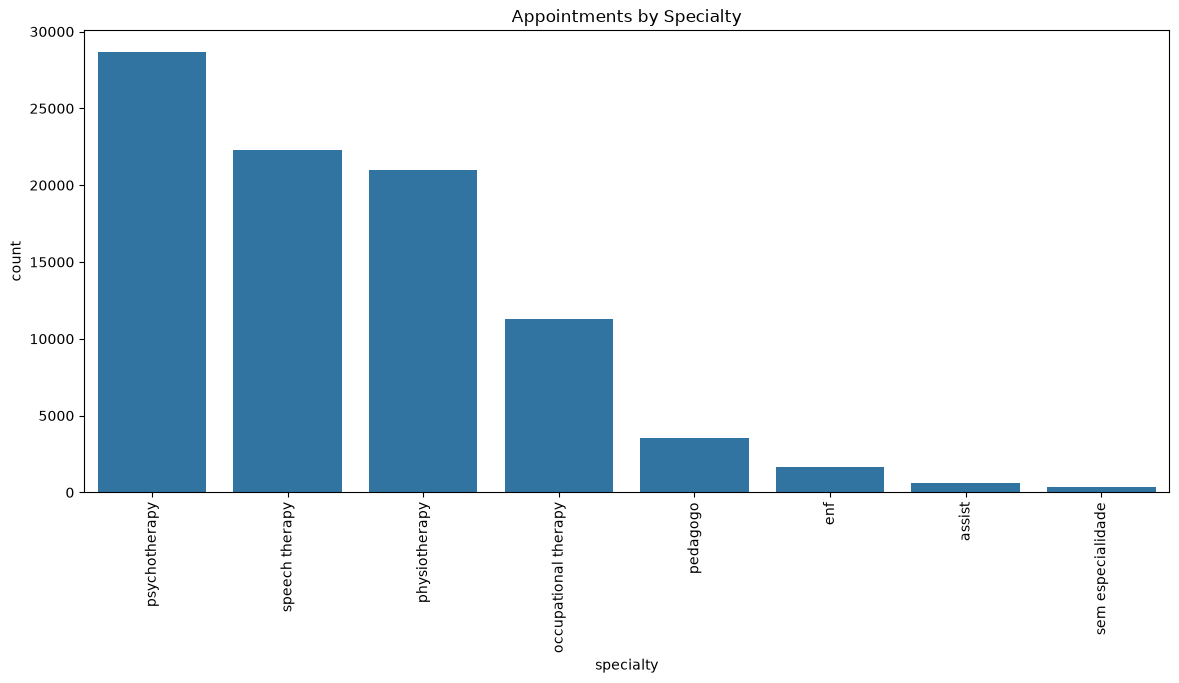

In [151]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    x='specialty',
    order=df['specialty'].value_counts().index
)

plt.xticks(rotation=90)

plt.title("Appointments by Specialty")

plt.show()

## Business Insight

The rehabilitation center provides services across multiple specialties, with **Psychotherapy**, **Speech Therapy**, and **Physiotherapy** accounting for the majority of appointments.

Psychotherapy has the highest appointment volume, indicating greater demand for mental health rehabilitation services, followed closely by Speech Therapy and Physiotherapy.

Understanding appointment distribution across specialties enables better workforce planning, resource allocation, and scheduling optimization.

In [ ]:
top_specialties = df['specialty'].value_counts().head(10).index

plt.figure(figsize=(12,6))

sns.countplot(
    data=df[df['specialty'].isin(top_specialties)],
    x='specialty',
    hue='no_show',
    order=top_specialties
)

plt.xticks(rotation=45)

plt.title("Top 10 Specialties vs Appointment Status")

plt.show()

## Business Insight

Appointment attendance varies across rehabilitation specialties.

While high-volume specialties naturally generate more no-show cases in absolute numbers, raw counts alone do not accurately represent patient attendance behavior.

To compare specialties fairly, no-show percentages should be analyzed, as they account for differences in appointment volume.

In [ ]:
plt.figure(figsize=(12,6))

specialty_percentage.sort_values(
    by='yes',
    ascending=False
)['yes'].plot(kind='bar')

plt.ylabel("No Show %")

plt.title("No Show Percentage by Specialty")

plt.show()

## Business Insight

Significant variation exists in no-show rates across different rehabilitation specialties.

Appointments without an assigned specialty (**sem especialidade**) exhibit the highest no-show rate (approximately **53%**), indicating that unclear or incomplete scheduling information may negatively affect patient attendance.

Among the clinical specialties, Physiotherapy and Psychotherapy demonstrate relatively higher no-show rates compared with Occupational Therapy and Pedagogo.

Pedagogo services record the lowest no-show rate (approximately **16%**), suggesting stronger patient commitment and appointment adherence.

These findings indicate that medical specialty is an important operational factor influencing appointment attendance and should be retained as a predictive feature in the machine learning model.

## Key Takeaways

- Psychotherapy accounts for the largest number of appointments.
- Speech Therapy and Physiotherapy are the next most frequently scheduled specialties.
- "Sem especialidade" has the highest no-show rate (~53%), indicating a potential scheduling or data quality issue.
- Pedagogo has the highest attendance rate and lowest no-show percentage.
- Appointment specialty is expected to be an important predictor for the classification model.

## Business Recommendation

The rehabilitation center should review appointments categorized as **"sem especialidade"** to determine whether incomplete scheduling information contributes to missed appointments.

Possible interventions include:

- Ensuring every appointment is assigned a valid specialty before confirmation.
- Providing specialty-specific appointment reminders.
- Allocating additional reminder efforts to specialties with historically higher no-show rates, such as Physiotherapy and Psychotherapy.
- Monitoring specialty-level attendance trends regularly to improve operational efficiency.

## Analytical Conclusion

Medical specialty demonstrates a clear relationship with appointment attendance.

The substantial variation in no-show rates across specialties indicates that scheduling characteristics influence patient behavior.

Therefore, specialty should be retained as an important feature during feature engineering and model development.

## 5.2 Appointment Shift Analysis

The appointment shift (Morning, Afternoon, Evening, etc.) may influence patient attendance due to work schedules, school timings, transportation availability, and patient preferences.

This analysis aims to identify whether appointment timing affects no-show behavior and whether specific shifts require additional reminder strategies or scheduling adjustments.

In [ ]:
print(df['appointment_shift'].value_counts(dropna=False))

In [ ]:
shift_percentage = (
    pd.crosstab(
        df['appointment_shift'],
        df['no_show'],
        normalize='index'
    ) * 100
).round(2)

shift_percentage.sort_values(
    by='yes',
    ascending=False
)

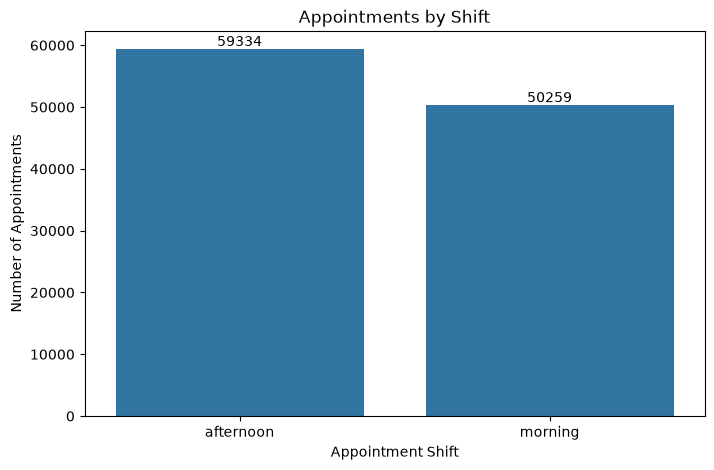

In [152]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='appointment_shift',
    order=df['appointment_shift'].value_counts().index
)

plt.title("Appointments by Shift")
plt.xlabel("Appointment Shift")
plt.ylabel("Number of Appointments")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Business Insight

The majority of appointments are scheduled during the **afternoon (59,334 appointments)**, while **50,259 appointments** are scheduled in the morning.

This indicates that the rehabilitation center experiences a slightly higher patient load during afternoon hours. Understanding this distribution helps in workforce planning, specialist allocation, and appointment scheduling.

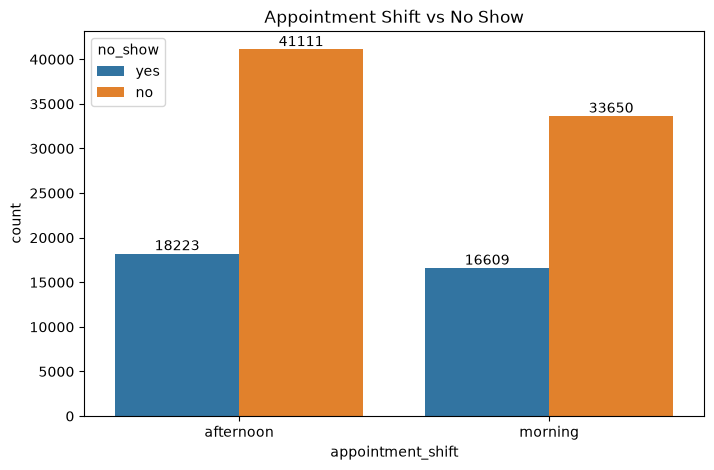

In [153]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='appointment_shift',
    hue='no_show',
    order=df['appointment_shift'].value_counts().index
)

plt.title("Appointment Shift vs No Show")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Business Insight

Although the afternoon shift handles more appointments than the morning shift, comparing raw appointment counts alone does not accurately represent attendance behavior.

To fairly evaluate patient attendance, the no-show percentage for each shift should be analyzed.

In [ ]:
plt.figure(figsize=(8,5))

shift_percentage['yes'].sort_values(
    ascending=False
).plot(kind='bar')

plt.ylabel("No Show Percentage")
plt.title("No Show Percentage by Appointment Shift")

plt.show()

## Business Insight

The **morning shift** records a higher no-show rate (**33.05%**) compared to the **afternoon shift (30.71%)**.

Although the difference is relatively small (approximately **2.34 percentage points**), it suggests that appointment timing may influence patient attendance. Patients scheduled in the morning may experience challenges such as transportation issues, work commitments, school schedules, or personal routines that increase the likelihood of missing appointments.

Appointment shift should therefore be considered as a potential predictive feature in the machine learning model.

## Key Takeaways

- Afternoon appointments account for the highest number of scheduled visits.
- Morning appointments have a slightly higher no-show rate than afternoon appointments.
- Appointment timing appears to have a moderate influence on patient attendance.
- Appointment shift is likely to contribute useful information during model training.

## Business Recommendation

Since morning appointments exhibit a slightly higher no-show rate, the rehabilitation center should consider implementing additional reminder strategies for patients scheduled during morning hours.

Possible interventions include:

- Sending reminder messages the evening before the appointment.
- Offering flexible rescheduling options for patients unable to attend early appointments.
- Monitoring morning attendance trends to optimize appointment scheduling.

## Analytical Conclusion

Appointment shift demonstrates a measurable relationship with patient attendance. While the difference between morning and afternoon attendance is not substantial, the observed variation suggests that appointment timing contributes to patient behavior.

Therefore, appointment shift should be retained as a feature during machine learning model development.

In [ ]:
print(df['appointment_time'].dtype)
print(df['appointment_time'].head(10))

## 5.3 Appointment Time Analysis

Appointment time may influence patient attendance due to work schedules, school timings, transportation availability, and personal preferences.

This section analyzes appointment hours to identify peak clinic hours and determine whether appointment timing affects no-show behavior.

In [ ]:
print(df['appointment_time'].value_counts().sort_index())

In [ ]:
plt.figure(figsize=(12,5))

ax = sns.countplot(
    data=df,
    x='appointment_time',
    order=sorted(df['appointment_time'].unique())
)

plt.title("Appointment Distribution by Hour")
plt.xlabel("Hour of Appointment")
plt.ylabel("Number of Appointments")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Business Insight

Appointments are concentrated between **8:00 AM and 5:00 PM**, with the highest appointment volumes observed during **1:00 PM (13:00)**, **9:00 AM**, and **2:00 PM (14:00)**.

Very few appointments are scheduled during **12:00 PM** and **6:00 PM (18:00)**, indicating these are low-demand operational hours.

Understanding appointment distribution helps optimize specialist scheduling and resource allocation throughout the day.

In [ ]:
hour_percentage = (
    pd.crosstab(
        df['appointment_time'],
        df['no_show'],
        normalize='index'
    ) * 100
).round(2)

hour_percentage

In [ ]:
plt.figure(figsize=(12,5))

hour_percentage['yes'].plot(
    kind='bar'
)

plt.ylabel("No Show Percentage")

plt.title("No Show Percentage by Appointment Hour")

plt.show()

## Business Insight

Patient attendance varies noticeably across appointment hours.

The highest no-show rate is observed at **10:00 AM (39.01%)**, followed by **5:00 PM (37.13%)**, making these the highest-risk appointment hours.

In contrast, appointments scheduled at **6:00 PM (14.16%)** and **12:00 PM (18.18%)** demonstrate the lowest no-show rates. However, these time slots contain relatively few appointments, so the results should be interpreted cautiously.

Overall, appointment hour appears to influence patient attendance and should be retained as an important temporal feature in the predictive model.

## Key Takeaways

- Peak appointment demand occurs between **9:00 AM and 2:00 PM**.
- **1:00 PM (13:00)** has the highest number of scheduled appointments.
- **10:00 AM** has the highest no-show rate (39.01%).
- **5:00 PM** also experiences a relatively high no-show rate (37.13%).
- Appointment hour demonstrates meaningful variation in patient attendance and is expected to improve model performance.

## Business Recommendation

The rehabilitation center should prioritize reminder strategies for appointments scheduled at **10:00 AM** and **5:00 PM**, as these hours exhibit the highest risk of patient absenteeism.

Additionally, clinic administrators may consider:

- Monitoring high-risk appointment hours regularly.
- Offering flexible rescheduling options for patients unable to attend during peak no-show periods.
- Allocating additional reminder notifications for appointments scheduled at higher-risk hours.

## Analytical Conclusion

Appointment hour exhibits a clear relationship with patient attendance.

The variation in no-show rates across different hours suggests that appointment timing influences patient behavior and should be included as a predictive feature during model development.

# 6. Temporal (Date) Analysis

Appointment dates play a crucial role in understanding patient demand patterns and forecasting future appointment volumes.

This section analyzes temporal trends, identifies seasonal patterns, and engineers date-related features that will be used in both classification and demand forecasting models.

In [ ]:
print(df['appointment_date_continuous'].dtype)

print()

print(df['appointment_date_continuous'].head(10))

print()

print(df['appointment_date_continuous'].describe())

In [ ]:
df['appointment_date_continuous'].sample(10)

In [ ]:
# Convert appointment date to datetime
df['appointment_date_continuous'] = pd.to_datetime(df['appointment_date_continuous'])

print(df['appointment_date_continuous'].dtype)

In [ ]:

# Feature Engineering - Date Features

df['Year'] = df['appointment_date_continuous'].dt.year
df['Month'] = df['appointment_date_continuous'].dt.month
df['Month_Name'] = df['appointment_date_continuous'].dt.month_name()

df['Day'] = df['appointment_date_continuous'].dt.day

df['Day_of_Week'] = df['appointment_date_continuous'].dt.day_name()

df['Week_Number'] = df['appointment_date_continuous'].dt.isocalendar().week

df['Quarter'] = df['appointment_date_continuous'].dt.quarter

print(df[['appointment_date_continuous',
          'Year',
          'Month',
          'Month_Name',
          'Day',
          'Day_of_Week',
          'Week_Number',
          'Quarter']].head())

In [ ]:
daily_appointments = (
    df.groupby('appointment_date_continuous')
      .size()
      .reset_index(name='Appointments')
)

daily_appointments.head()

In [ ]:
plt.figure(figsize=(16,5))

plt.plot(
    daily_appointments['appointment_date_continuous'],
    daily_appointments['Appointments']
)

plt.title("Daily Appointment Volume")

plt.xlabel("Date")

plt.ylabel("Appointments")

plt.grid(True)

plt.show()

## Business Insight

The dataset contains appointment records spanning **498 continuous calendar days**, making it suitable for time-series analysis and demand forecasting.

Daily appointment counts fluctuate over time, indicating variations in patient demand across different dates. These temporal patterns will be valuable for building a demand forecasting model that predicts future appointment volumes.

In [ ]:
monthly = (
    df.groupby('Month_Name')
      .size()
      .reindex([
          'January','February','March','April',
          'May','June','July','August',
          'September','October','November','December'
      ])
)

monthly

In [ ]:
plt.figure(figsize=(10,5))

monthly.plot(kind='bar')

plt.title("Appointments by Month")

plt.ylabel("Appointments")

plt.show()

## Business Insight

Appointment volume varies across different months. February records the highest number of appointments, followed by March and April, while November and December contain comparatively fewer appointments.

Since the dataset does not contain an equal number of records for every month, these differences should not be interpreted solely as seasonal demand changes. Nevertheless, monthly information may still capture useful temporal patterns and should be retained as a predictive feature.

## Key Takeaways

- February has the highest appointment volume.
- March and April also experience high patient demand.
- November and December contain relatively fewer appointment records.
- Month-based features may help capture seasonal variations in demand forecasting.

In [ ]:
weekday = (
    df.groupby('Day_of_Week')
      .size()
      .reindex([
          'Monday','Tuesday','Wednesday',
          'Thursday','Friday','Saturday','Sunday'
      ])
)

weekday

In [ ]:
plt.figure(figsize=(10,5))

weekday.plot(kind='bar')

plt.title("Appointments by Day of Week")

plt.ylabel("Appointments")

plt.show()

## Business Insight

Appointments are distributed throughout the week, with Thursday recording the highest appointment volume, followed by Friday and Saturday.

Sunday has the lowest number of appointments, suggesting reduced clinic activity or limited service availability during weekends.

Understanding weekday demand helps optimize specialist scheduling and workforce planning.

In [ ]:
weekday_percentage = (
    pd.crosstab(
        df['Day_of_Week'],
        df['no_show'],
        normalize='index'
    ) * 100
).round(2)

weekday_percentage = weekday_percentage.reindex([
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
])

weekday_percentage

## Business Insight

The no-show rate remains relatively consistent across all days of the week, ranging between **31.21% and 32.71%**.

Sunday records the highest no-show rate (32.71%), while Tuesday has the lowest (31.21%). However, the differences are relatively small, suggesting that the day of the week has only a modest influence on patient attendance.

Although its standalone predictive power may be limited, the day of the week should still be retained as a temporal feature because it may interact with appointment timing, specialty, and seasonal patterns.

## Key Takeaways

- Thursday has the highest appointment demand.
- Sunday records the highest no-show rate.
- Tuesday has the lowest no-show rate.
- No-show percentages remain relatively stable throughout the week.
- Day of the week may provide additional predictive value when combined with other temporal features.

## Business Recommendation

Since appointment demand varies throughout the week, the rehabilitation center should allocate specialists based on expected patient volume, particularly during high-demand weekdays such as Thursday and Friday.

Although weekday differences in no-show rates are relatively small, appointment reminders should continue to be provided consistently throughout the week rather than focusing on a single day.

## Analytical Conclusion

Temporal features provide valuable information for both machine learning tasks.

While the day of the week shows only a modest relationship with appointment attendance, monthly and daily appointment trends are expected to play an important role in demand forecasting.

Therefore, all engineered temporal features should be retained for further modeling and feature importance evaluation.

# 7. Weather Analysis

Environmental conditions such as temperature, rainfall, and storms may influence patient attendance, particularly for individuals traveling long distances or requiring physical rehabilitation.

This section investigates the relationship between weather conditions and appointment attendance to identify whether environmental factors contribute to no-show behavior and should be incorporated into predictive models.

In [ ]:
weather_features = [
    'average_temp_day',
    'max_temp_day',
    'average_rain_day',
    'max_rain_day',
    'heat_intensity',
    'rain_intensity',
    'rainy_day_before',
    'storm_day_before'
]

df[weather_features].describe()

## Business Insight

The dataset contains several weather-related variables, including temperature, rainfall, rainfall intensity, heat intensity, and indicators of rainy or stormy conditions from the previous day.

Temperature variables have only a small number of missing values (approximately 2%), while categorical weather indicators are complete with no missing records.

The availability of these environmental variables provides an opportunity to evaluate whether weather conditions influence patient attendance and appointment demand.

In [ ]:
df[weather_features].isnull().sum()

## Key Takeaways

- Weather variables contain only a small percentage of missing values (around 2%).
- Binary weather indicators (`rainy_day_before` and `storm_day_before`) have no missing values.
- Missing weather values can be safely handled during preprocessing using appropriate imputation techniques.

In [ ]:
for col in [
    'average_temp_day',
    'max_temp_day',
    'average_rain_day',
    'max_rain_day'
]:

    plt.figure(figsize=(8,4))

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True
    )

    plt.title(col)

    plt.show()

In [ ]:
analyze_binary_feature(df, 'rainy_day_before')

## Business Insight

A strong relationship exists between rainfall on the previous day and appointment attendance.

When the previous day was **not rainy**, the no-show rate increased to **56.11%**, whereas appointments following rainy days recorded a much lower no-show rate of **30.16%**.

This suggests that recent weather conditions influence patient behavior and should be considered during appointment planning and predictive modeling.

## Key Takeaways

- Previous-day weather appears strongly associated with appointment attendance.
- Patients in the `0` category exhibit substantially higher no-show rates than those in the `1` category.
- The encoding should be verified during data preprocessing.

In [ ]:
analyze_binary_feature(df, 'storm_day_before')

## Business Insight

Storm conditions on the previous day also demonstrate a strong relationship with patient attendance.

Appointments associated with the `0` category exhibit a no-show rate of **56.22%**, while the `1` category records only **30.15%**.

This indicates that previous-day weather conditions may influence appointment behavior and should be retained for further analysis.

## Key Takeaways

- Storm-related variables exhibit a strong association with no-show behavior.
- Feature encoding should be validated before model development.
- The feature should be retained for predictive modeling.

In [ ]:
print(df['rain_intensity'].value_counts(dropna=False))

rain_percentage = (
    pd.crosstab(
        df['rain_intensity'],
        df['no_show'],
        normalize='index'
    ) * 100
).round(2)

rain_percentage

## Business Insight

Rain intensity demonstrates a modest relationship with patient attendance.

Patients attending during **moderate rainfall** exhibit the highest no-show rate (**33.20%**), followed by **heavy rain (32.77%)** and **weak rain (32.51%)**.

Appointments on **days without rain** record the lowest no-show rate (**31.30%**), suggesting that rainfall slightly increases the likelihood of missed appointments.

## Key Takeaways

- Moderate rainfall is associated with the highest no-show percentage.
- No-rain conditions produce the best attendance.
- Rain intensity contributes useful environmental information.

In [ ]:
print(df['heat_intensity'].value_counts(dropna=False))

heat_percentage = (
    pd.crosstab(
        df['heat_intensity'],
        df['no_show'],
        normalize='index'
    ) * 100
).round(2)

heat_percentage

## Business Insight

Heat intensity has a noticeable impact on appointment attendance.

Patients scheduled during **heavy cold** conditions record the highest no-show rate (**52.93%**), followed by **heavy warm** conditions (**38.79%**).

In contrast, appointments during **mild** weather experience the lowest no-show rate (**26.10%**), indicating substantially better attendance.

These findings suggest that extreme weather conditions may discourage patients from attending rehabilitation appointments, whereas moderate weather supports higher attendance.

## Key Takeaways

- Heavy cold weather produces the highest no-show rate.
- Mild weather demonstrates the strongest appointment attendance.
- Extreme environmental conditions appear to reduce patient attendance.
- Heat intensity is likely to be an important predictive feature.

## Business Recommendation

The rehabilitation center should consider incorporating weather forecasts into appointment management strategies.

Possible interventions include:

- Sending additional reminders before appointments during extreme weather conditions.
- Offering flexible rescheduling during severe weather events.
- Increasing telehealth availability, where appropriate, during adverse weather.
- Using weather forecasts as an input for demand planning and staffing decisions.

## Analytical Conclusion

Weather variables demonstrate measurable relationships with patient attendance.

Among all environmental variables, **heat intensity**, **rainy day before**, and **storm day before** exhibit the strongest associations with no-show behavior.

These variables should be retained for feature engineering and evaluated further during machine learning model development.

# 8. Geographic (Location) Analysis

The rehabilitation center serves patients from multiple cities within its service region. Understanding appointment demand and no-show behavior across different locations helps optimize specialist allocation, outreach programs, and operational planning.

This section analyzes appointment distribution and attendance patterns by location to identify high-demand areas and cities with higher no-show risk.

In [ ]:
print("Number of Unique Places:", df['place'].nunique())
print()

print(df['place'].value_counts(dropna=False))

In [ ]:
place_percentage = (
    pd.crosstab(
        df['place'],
        df['no_show'],
        normalize='index'
    ) * 100
).round(2)

place_percentage.sort_values(
    by='yes',
    ascending=False
)

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='place',
    order=df['place'].value_counts().index
)

plt.title("Appointments by Location")
plt.xlabel("Number of Appointments")
plt.ylabel("City")

plt.show()

## Business Insight

The rehabilitation center primarily serves patients from a limited number of major cities, with **ITAJAÍ** contributing the highest number of appointments, followed by **Balneário Camboriú**, **Camboriú**, **Navegantes**, and **Itapema**.

The dataset also contains a large number of additional location names with very few records. These appear to be anonymized or synthetic values and should be interpreted cautiously during analysis.

In [ ]:
plt.figure(figsize=(12,6))

place_percentage['yes'].sort_values(
    ascending=False
).plot(kind='barh')

plt.xlabel("No-show Percentage")
plt.title("No-show Percentage by Location")

plt.show()

## Business Insight

Among the major service locations, no-show rates remain relatively low and consistent, generally ranging between **6% and 14%**.

Locations such as **Luiz Alves (13.58%)** and **Ilhota (13.21%)** exhibit comparatively higher no-show rates than the other major cities, while **Penha (6.16%)** and **Balneário Piçarras (6.67%)** demonstrate the best attendance.

Several locations with extremely high no-show percentages are based on very small sample sizes and therefore should not be used for operational decision-making.

## Key Takeaways

- ITAJAÍ contributes the largest share of appointments.
- The majority of appointments originate from a small group of core service cities.
- Luiz Alves and Ilhota show relatively higher no-show rates among the major locations.
- Penha and Balneário Piçarras demonstrate the strongest patient attendance.
- Rare locations with very few records should not influence business decisions.

## Business Recommendation

The rehabilitation center should prioritize staffing and resource allocation in high-volume cities such as ITAJAÍ, Balneário Camboriú, Camboriú, and Navegantes.

Cities with comparatively higher no-show rates, such as Luiz Alves and Ilhota, may benefit from enhanced reminder strategies or additional patient engagement initiatives.

Rare locations containing only a few appointments should be grouped into an "Other" category during preprocessing to improve model stability.

## Analytical Conclusion

Geographic location provides useful operational information regarding appointment demand.

Although location appears valuable for predicting attendance, high-cardinality location values should be carefully handled during preprocessing. Rare categories will be grouped to reduce noise and improve model generalization.

# 9. Overall EDA Summary

## Key Findings

### Patient Demographics
- The dataset is moderately imbalanced, with approximately 68% attended appointments and 32% no-shows.
- Young adults exhibit the highest no-show rate, while senior patients demonstrate the best attendance.
- Patients requiring a companion are more likely to attend their appointments.

### Health Conditions
- Hypertension and diabetes are associated with slightly better attendance.
- Scholarship status and SMS reminders show minimal individual influence on attendance.
- Health-related variables should still be retained for model evaluation.

### Appointment Characteristics
- Appointment specialty significantly influences attendance patterns.
- Morning appointments experience slightly higher no-show rates than afternoon appointments.
- Appointment hour demonstrates meaningful variation, with 10:00 AM showing the highest no-show rate.

### Temporal Patterns
- Appointment demand varies throughout the year and across weekdays.
- Thursday records the highest appointment volume.
- Temporal features are expected to improve demand forecasting performance.

### Weather Conditions
- Heat intensity demonstrates one of the strongest relationships with appointment attendance.
- Heavy cold weather is associated with the highest no-show rate.
- Weather variables should be incorporated into predictive models.

### Geographic Patterns
- Most appointments originate from a small number of core cities.
- Geographic information provides valuable operational insights for staffing and resource allocation.

# 10. Business Recommendations

Based on the exploratory data analysis, the following recommendations are proposed:

1. Prioritize reminder campaigns for high-risk patient groups, particularly young adults and appointments scheduled during high no-show hours.

2. Incorporate weather forecasts into scheduling decisions, especially during periods of extreme weather.

3. Allocate additional specialists to high-demand cities and peak appointment periods.

4. Use appointment specialty and temporal features when predicting no-show risk.

5. Group infrequent location categories during preprocessing to improve model performance.

6. Continue evaluating health-related variables as they may contribute additional predictive value when combined with other features.

7. Develop a real-time prediction system capable of identifying high-risk appointments before the scheduled visit.

# 11. Next Steps

The exploratory data analysis identified several important predictors of patient attendance, including demographic, temporal, environmental, geographic, and appointment-related variables.

The next phase of the project focuses on:

- Data preprocessing
- Missing value treatment
- Feature engineering
- Encoding categorical variables
- Addressing class imbalance
- Training and evaluating multiple machine learning models
- Selecting the best-performing classification model for deployment